In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
df=pd.read_csv("cleaned_dataset.csv")
df.head()

,year,month,day,max_temp_C,min_temp_C,avg_temp_c,humidity,precipprob,windgust,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,uvindex,precipitation,rain
0,2015,1,1,15.94,3.94,10.00,74.7,100,11.2,5.8,1020.4,79.1,2.4,96.6,4,0.8,1
1,2015,1,2,21.67,9.94,12.72,80.1,100,19.9,9.2,1022.2,93.3,2.9,40.4,2,0.0,0
2,2015,1,3,19.83,8.94,12.67,86.3,100,15.4,15.7,1021.0,90.3,2.8,58.6,4,0.5,1
3,2015,1,4,21.06,8.94,12.50,85.5,100,17.0,9.2,1018.1,67.1,2.7,118.0,6,0.5,1
4,2015,1,5,17.94,5.94,10.72,83.2,0,16.3,10.3,1013.9,41.6,3.9,139.2,6,0.0,0


In [111]:
df.columns

Index(['year', 'month', 'day', 'max_temp_C', 'min_temp_C', 'avg_temp_c',
       'humidity', 'precipprob', 'windgust', 'windspeed', 'sealevelpressure',
       'cloudcover', 'visibility', 'solarradiation', 'uvindex',
       'precipitation', 'rain'],
      dtype='object')

In [112]:
df.head()

,year,month,day,max_temp_C,min_temp_C,avg_temp_c,humidity,precipprob,windgust,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,uvindex,precipitation,rain
0,2015,1,1,15.94,3.94,10.00,74.7,100,11.2,5.8,1020.4,79.1,2.4,96.6,4,0.8,1
1,2015,1,2,21.67,9.94,12.72,80.1,100,19.9,9.2,1022.2,93.3,2.9,40.4,2,0.0,0
2,2015,1,3,19.83,8.94,12.67,86.3,100,15.4,15.7,1021.0,90.3,2.8,58.6,4,0.5,1
3,2015,1,4,21.06,8.94,12.50,85.5,100,17.0,9.2,1018.1,67.1,2.7,118.0,6,0.5,1
4,2015,1,5,17.94,5.94,10.72,83.2,0,16.3,10.3,1013.9,41.6,3.9,139.2,6,0.0,0


In [113]:
df["rain"] = (df["precipitation"] > 0).astype(int)

In [114]:
df.head()

,year,month,day,max_temp_C,min_temp_C,avg_temp_c,humidity,precipprob,windgust,windspeed,sealevelpressure,cloudcover,visibility,solarradiation,uvindex,precipitation,rain
0,2015,1,1,15.94,3.94,10.00,74.7,100,11.2,5.8,1020.4,79.1,2.4,96.6,4,0.8,1
1,2015,1,2,21.67,9.94,12.72,80.1,100,19.9,9.2,1022.2,93.3,2.9,40.4,2,0.0,0
2,2015,1,3,19.83,8.94,12.67,86.3,100,15.4,15.7,1021.0,90.3,2.8,58.6,4,0.5,1
3,2015,1,4,21.06,8.94,12.50,85.5,100,17.0,9.2,1018.1,67.1,2.7,118.0,6,0.5,1
4,2015,1,5,17.94,5.94,10.72,83.2,0,16.3,10.3,1013.9,41.6,3.9,139.2,6,0.0,0


In [115]:
X=df.drop(columns=["rain","precipitation","precipprob"])
y=df["rain"]

In [116]:

print(X.shape)
y.value_counts()

(3468, 14)


rain
0    2107
1    1361
Name: count, dtype: int64

In [117]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

In [118]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

preprocessing_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # safety net for future missing readings
    ('classifier', RandomForestClassifier(random_state=42))
])

preprocessing_pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('classifier', RandomForestClassifier(random_state=42))])

In [119]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, 
                              AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           roc_auc_score, roc_curve, confusion_matrix, classification_report,
                           mean_squared_error, mean_absolute_error, r2_score)
from sklearn.model_selection import train_test_split, KFold ,cross_val_score

C:\Users\acer\AppData\Local\Temp\ipykernel_17556\392924733.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=models.keys())


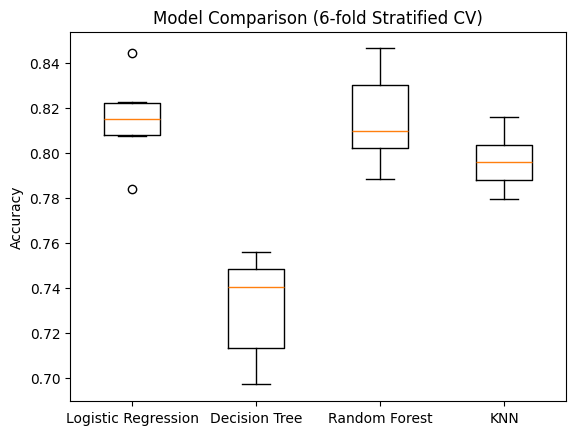

In [120]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000))
    ]),
    'Decision Tree': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'KNN': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(n_neighbors=6))
    ])
}

results = []
kf = StratifiedKFold(n_splits=6, random_state=42, shuffle=True)

for model in models.values():
    cv_results = cross_val_score(model, X_train, y_train, cv=kf)
    results.append(cv_results)

plt.boxplot(results, labels=models.keys())
plt.ylabel("Accuracy")
plt.title("Model Comparison (6-fold Stratified CV)")
plt.show()

In [121]:
for name, model in models.items():
    model.fit(X_train, y_train)
    test_score = model.score(X_test, y_test)
    print("{} Test Set Accuracy: {:.4f}".format(name, test_score))

Logistic Regression Test Set Accuracy: 0.8184
Decision Tree Test Set Accuracy: 0.7666
Random Forest Test Set Accuracy: 0.8372
KNN Test Set Accuracy: 0.8127


In [122]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # metric
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")


Logistic Regression:
  Accuracy:  0.8184
  Precision: 0.7724
  Recall:    0.7610
  F1-Score:  0.7667
  ROC-AUC:   0.8677

Decision Tree:
  Accuracy:  0.7666
  Precision: 0.7037
  Recall:    0.6985
  F1-Score:  0.7011
  ROC-AUC:   0.7545

Random Forest:
  Accuracy:  0.8372
  Precision: 0.8167
  Recall:    0.7537
  F1-Score:  0.7839
  ROC-AUC:   0.8956

KNN:
  Accuracy:  0.8127
  Precision: 0.8170
  Recall:    0.6728
  F1-Score:  0.7379
  ROC-AUC:   0.8736


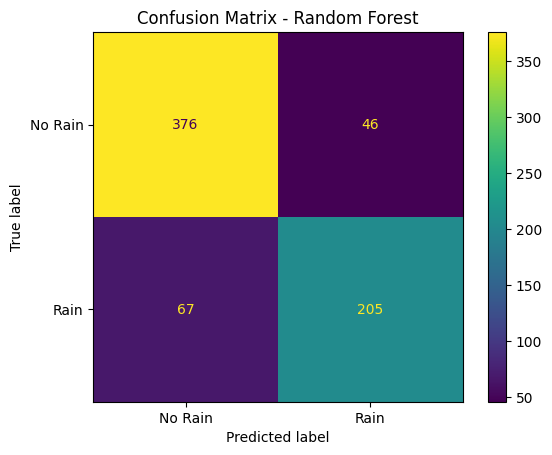

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = models['Random Forest'] 
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Rain", "Rain"])
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

In [124]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred, target_names=['NO Rain','Rain']))

              precision    recall  f1-score   support

     NO Rain       0.85      0.89      0.87       422
        Rain       0.82      0.75      0.78       272

    accuracy                           0.84       694
   macro avg       0.83      0.82      0.83       694
weighted avg       0.84      0.84      0.84       694



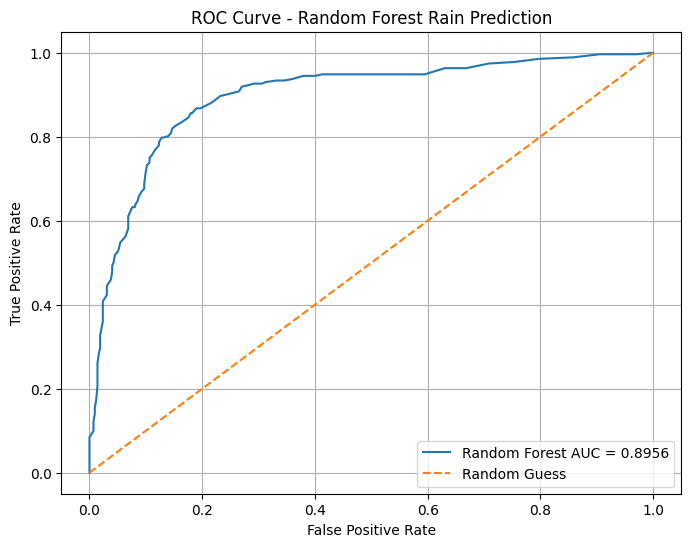

In [125]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

best_model = models['Random Forest']   
best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Rain Prediction")
plt.legend()
plt.grid(True)
plt.show()

In [126]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.named_steps['classifier'].feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
6,humidity,0.193720
10,cloudcover,0.107372
5,avg_temp_c,0.104945
9,sealevelpressure,0.097601
4,min_temp_C,0.091710
12,solarradiation,0.074245
11,visibility,0.052318
7,windgust,0.051340
1,month,0.046144
2,day,0.045831


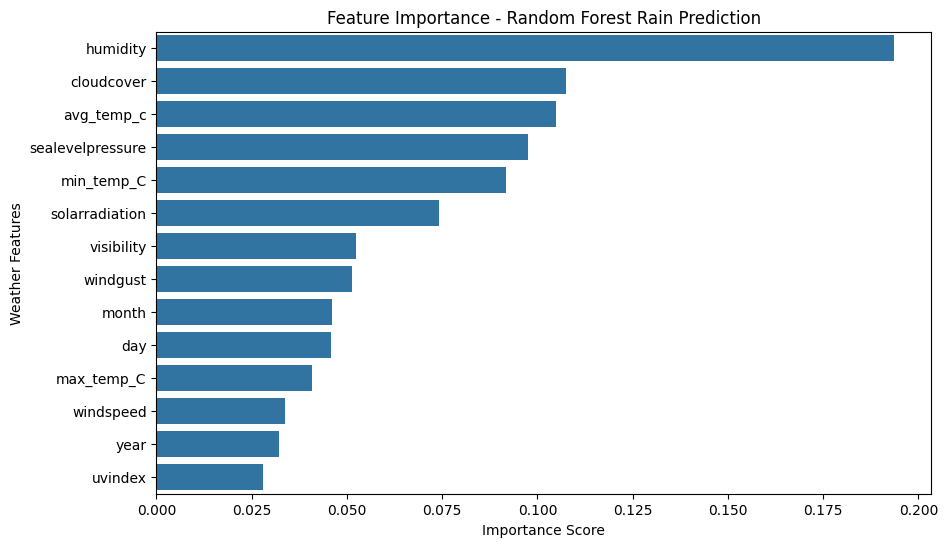

In [127]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest Rain Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Weather Features")
plt.show()

After removing precipprob from the input features, humidity became the most important predictor of rainfall in Kathmandu. This shows that the model is no longer depending on direct precipitation probability and is instead learning from natural weather conditions. Minimum temperature, average temperature, sea level pressure, cloud cover, and solar radiation also contributed strongly to the prediction. These variables are logically related to rainfall because rain is influenced by moisture, temperature changes, cloud formation, and atmospheric pressure.

In [128]:
# Example: predict rain for a hypothetical day's conditions
sample = pd.DataFrame([{
    'max_temp_C': 29.5, 'min_temp_C': 16.1, 'avg_temp_c': 22.76,
    'humidity': 83.4, 'windgust': 27.17, 'windspeed': 9.23,
    'sealevelpressure': 1003, 'cloudcover': 49.5, 'visibility': 8,
    'solarradiation': 22.81, 'uvindex': 0  , 'year': 2026, 'month': 6,'day':1
}])[X.columns] 

pred = best_model.predict(sample)[0]
proba = best_model.predict_proba(sample)[0]

print("Prediction:", "Rain" if pred == 1 else "No Rain")
print(f"P(No Rain): {proba[0]:.3f}  P(Rain): {proba[1]:.3f}")

Prediction: Rain
P(No Rain): 0.310  P(Rain): 0.690


In [129]:
df.columns

Index(['year', 'month', 'day', 'max_temp_C', 'min_temp_C', 'avg_temp_c',
       'humidity', 'precipprob', 'windgust', 'windspeed', 'sealevelpressure',
       'cloudcover', 'visibility', 'solarradiation', 'uvindex',
       'precipitation', 'rain'],
      dtype='object')

In [134]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

# Step 1: build a proper monthly time series -- % of days with rain, each month, each year
monthly = df.groupby(['year', 'month']).agg(rainy_days_pct=('rain', 'mean')).reset_index()
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))
monthly = monthly.set_index('date').sort_index()

# Step 2: expose and fix any gaps in the series (this dataset has a real 12-month
# gap between mid-2015 and mid-2016 -- reindexing surfaces it instead of hiding it)
full_index = pd.date_range(monthly.index.min(), monthly.index.max(), freq='MS')
monthly_full = monthly.reindex(full_index)

ts = monthly_full['rainy_days_pct'] * 100
ts = ts.interpolate(method='time')
ts = ts.fillna(ts.groupby(ts.index.month).transform('mean'))  # fill any remaining gaps seasonally
ts = ts.asfreq('MS')

# Step 3: logit transform -- makes it mathematically impossible for the forecast
# to fall outside 0-100%, instead of clipping an already-broken number afterward
p = ts / 100
p = p.clip(0.01, 0.99)
ts_logit = np.log(p / (1 - p))

# Step 4: fit SARIMA on the logit-transformed series
model = SARIMAX(ts_logit, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False, enforce_invertibility=False)
fit = model.fit(disp=False)

# Step 5: forecast forward far enough to cover all of calendar year 2026
months_ahead = (pd.Timestamp('2026-12-01').to_period('M') - ts.index[-1].to_period('M')).n
forecast = fit.get_forecast(steps=months_ahead)
forecast_logit = forecast.predicted_mean
ci_logit = forecast.conf_int(alpha=0.20)  # 80% confidence interval

# Step 6: convert back to percentage -- guaranteed to stay within 0-100
def logit_to_pct(x):
    return 100 / (1 + np.exp(-x))

forecast_pct = forecast_logit.apply(logit_to_pct)
lower_pct = ci_logit.iloc[:, 0].apply(logit_to_pct)
upper_pct = ci_logit.iloc[:, 1].apply(logit_to_pct)

# Step 7: build the results table, filtered to calendar year 2026
monthly_predictions = []
for date, pred, lower, upper in zip(forecast_pct.index, forecast_pct.values,
                                      lower_pct.values, upper_pct.values):
    if date.year == 2026:
        monthly_predictions.append({
            "Year": date.year,
            "Month": date.month,
            "Month Name": month_names[date.month],
            "Predicted Rainy Days (%)": round(pred, 1),
            "Lower Bound (80% CI)": round(lower, 1),
            "Upper Bound (80% CI)": round(upper, 1)
        })

monthly_prediction_df = pd.DataFrame(monthly_predictions)
monthly_prediction_df

,Year,Month,Month Name,Predicted Rainy Days (%),Lower Bound (80% CI),Upper Bound (80% CI)
0,2026,1,January,7.6,1.5,30.3
1,2026,2,February,11.5,2.3,41.3
2,2026,3,March,33.9,8.4,74.0
3,2026,4,April,27.8,6.3,68.8
4,2026,5,May,57.9,19.0,88.9
5,2026,6,June,70.6,28.7,93.5
6,2026,7,July,95.9,77.7,99.4
7,2026,8,August,90.1,56.3,98.5
8,2026,9,September,72.1,26.2,95.0
9,2026,10,October,25.2,4.3,71.7


In [133]:
import joblib

joblib.dump(best_model, 'rain_prediction.pkl')
print("Saved pipeline: rain_prediction.pkl")

Saved pipeline: rain_prediction.pkl
